# Training vs Real-Time Inference Debug Notebook

## Forensic Comparison for BiLSTM MediaPipe Sign Language Model

This notebook systematically compares training data with live real-time captures to identify mismatches in:
- Feature extraction and preprocessing
- MediaPipe handedness and image orientation
- Coordinate normalization and scaling
- Model prediction confidence differences

**Objective**: Debug why the model performs well on training data but may have issues with live inference.

---

## Section 1: Load & Inspect Baseline

Load the pre-trained model and a specific training sample to establish baseline metrics for feature comparison.


In [1]:
import sys
import numpy as np
import pandas as pd
import cv2
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = Path('/home/mathew/Arrakis/SIGN2SOUND_Kaizen')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import project modules
from models.model import load_model
from features.hand_landmarks import HandLandmarkDetector
from features.feature_utils import pad_or_truncate
from inference.feature_processing import normalize_landmarks_wrist_relative, LandmarkSmoother
from inference.utils import load_class_mapping

print("✓ All imports successful")
print(f"Project root: {PROJECT_ROOT}")

✓ All imports successful
Project root: /home/mathew/Arrakis/SIGN2SOUND_Kaizen


In [2]:
# Load the pre-trained model
MODEL_PATH = PROJECT_ROOT / 'checkpoints' / 'best_model.pth'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Loading model from: {MODEL_PATH}")
model, checkpoint = load_model(str(MODEL_PATH), device=DEVICE)
model.eval()

print(f"\n✓ Model loaded successfully")
print(f"  Model type: {checkpoint.get('model_type', 'unknown')}")
print(f"  Loss type: {checkpoint.get('loss_type', 'unknown')}")
print(f"  Device: {DEVICE}")

# Load class mapping
csv_path = PROJECT_ROOT / 'data' / 'processed' / 'class_mapping.csv'
class_mapping = load_class_mapping(str(csv_path))
print(f"✓ Loaded {len(class_mapping)} classes")

Loading model from: /home/mathew/Arrakis/SIGN2SOUND_Kaizen/checkpoints/best_model.pth


INFO:models.model:Loading model type: bilstm_ctc
INFO:models.model:BiLSTM CTC Model initialized: 2,376,217 parameters
INFO:models.model:Model loaded from /home/mathew/Arrakis/SIGN2SOUND_Kaizen/checkpoints/best_model.pth
INFO:models.model:Epoch: 7
INFO:models.model:Val Accuracy: 97.59%
INFO:models.model:Loss type: ctc
INFO:inference.utils:Loaded 25 classes from /home/mathew/Arrakis/SIGN2SOUND_Kaizen/data/processed/class_mapping.csv



✓ Model loaded successfully
  Model type: bilstm_ctc
  Loss type: ctc
  Device: cuda
✓ Loaded 25 classes


In [3]:
# Load a training sample for comparison (sign 'A' - class 0)
TRAINING_DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'features'

# Find a sample for class 0 (A)
class_0_files = list(TRAINING_DATA_DIR.glob('class_0_sample_*.npy'))
if class_0_files:
    sample_file = sorted(class_0_files)[0]  # First sample
    training_sample = np.load(sample_file)
    print(f"\n✓ Loaded training sample: {sample_file.name}")
    print(f"  Shape: {training_sample.shape}")
    print(f"  dtype: {training_sample.dtype}")
else:
    print("ERROR: No training samples found!")
    training_sample = None

# Print baseline metrics
if training_sample is not None:
    print(f"\n=== BASELINE STATISTICS (Training Sample) ===")
    print(f"Shape: {training_sample.shape}")
    print(f"Min: {training_sample.min():.6f}")
    print(f"Max: {training_sample.max():.6f}")
    print(f"Mean: {training_sample.mean():.6f}")
    print(f"Std: {training_sample.std():.6f}")
    print(f"Median: {np.median(training_sample):.6f}")
    
    # Per-frame statistics
    if training_sample.ndim == 2:
        print(f"\nPer-frame statistics (shape: {training_sample.shape}):")
        frame_means = training_sample.mean(axis=1)
        print(f"  Frame mean values (min/max): [{frame_means.min():.4f}, {frame_means.max():.4f}]")
        print(f"  Frame std values (min/max): [{training_sample.std(axis=1).min():.4f}, {training_sample.std(axis=1).max():.4f}]")


✓ Loaded training sample: class_0_sample_0.npy
  Shape: (60, 126)
  dtype: float32

=== BASELINE STATISTICS (Training Sample) ===
Shape: (60, 126)
Min: -0.030884
Max: 0.794185
Mean: 0.005891
Std: 0.059697
Median: 0.000000

Per-frame statistics (shape: (60, 126)):
  Frame mean values (min/max): [0.0000, 0.3534]
  Frame std values (min/max): [0.0000, 0.3016]


## Section 2: Live 'Frozen' Capture

Capture a single frozen sequence (30 frames) from the webcam using the project's MediaPipe extraction logic. This captures one sequence only - no continuous loop.


In [4]:
# Capture configuration
CAPTURE_FRAMES = 30  # Number of frames to capture
CAPTURE_DELAY = 33   # Milliseconds between frames (30 FPS)

print("="*70)
print("LIVE WEBCAM CAPTURE")
print("="*70)
print(f"Preparing to capture {CAPTURE_FRAMES} frames from webcam...")
print("Press 'SPACE' to start capture")
print("Capture will run for approximately", CAPTURE_FRAMES * CAPTURE_DELAY / 1000, "seconds")
print("="*70)

# Initialize detector
detector = HandLandmarkDetector(
    static_image_mode=False,  # Video mode
    max_num_hands=2,
    min_detection_confidence=0.3,
    min_tracking_confidence=0.3
)

# Storage for live data
live_frames = []
live_landmarks_list = []
live_handedness_list = []
capture_started = False
frame_idx = 0

# Open webcam
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("\nWebcam opened. Starting capture loop...")
print("Press SPACE to start, ESC to cancel\n")

while True:
    ret, frame = cap.read()
    if not ret:
        print("ERROR: Failed to read from webcam")
        break
    
    # Mirror frame for selfie-view
    frame_display = cv2.flip(frame, 1)
    
    # Display status
    status_text = "PRESS SPACE TO START" if not capture_started else f"CAPTURING: {frame_idx+1}/{CAPTURE_FRAMES}"
    cv2.putText(frame_display, status_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    # Show frame
    cv2.imshow('Webcam Capture (Press SPACE to start, ESC to cancel)', frame_display)
    
    key = cv2.waitKey(CAPTURE_DELAY) & 0xFF
    
    # Start capture on SPACE
    if key == 32 and not capture_started:  # SPACE
        capture_started = True
        print("✓ Capture started!")
        live_frames = []
        live_landmarks_list = []
        live_handedness_list = []
        frame_idx = 0
    
    # Cancel on ESC
    if key == 27:  # ESC
        print("✗ Capture cancelled")
        break
    
    # Capture frames if started
    if capture_started:
        # Store frame
        live_frames.append(frame_display.copy())
        
        # Extract landmarks
        landmarks = detector.process_image(frame)
        live_landmarks_list.append(landmarks)
        
        frame_idx += 1
        
        if frame_idx >= CAPTURE_FRAMES:
            print(f"✓ Capture complete! Captured {CAPTURE_FRAMES} frames")
            break

cap.release()
cv2.destroyAllWindows()

# Convert to numpy arrays
live_sequence = None
if live_landmarks_list and all(l is not None for l in live_landmarks_list):
    live_sequence = np.array(live_landmarks_list)
    print(f"\n✓ Live sequence shape: {live_sequence.shape}")
    print(f"  dtype: {live_sequence.dtype}")
else:
    print("\n⚠ WARNING: Not all frames had hand landmarks detected!")
    if live_landmarks_list:
        detected = sum(1 for l in live_landmarks_list if l is not None)
        print(f"  Frames with landmarks: {detected}/{len(live_landmarks_list)}")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1769670048.817692   15674 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1769670048.845891   15684 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
INFO:features.hand_landmarks:HandLandmarkDetector initialized (confidence=0.3)


LIVE WEBCAM CAPTURE
Preparing to capture 30 frames from webcam...
Press 'SPACE' to start capture
Capture will run for approximately 0.99 seconds

Webcam opened. Starting capture loop...
Press SPACE to start, ESC to cancel



QObject::moveToThread: Current thread (0xe6f9270) is not the object's thread (0xeb0c590).
Cannot move to target thread (0xe6f9270)

QObject::moveToThread: Current thread (0xe6f9270) is not the object's thread (0xeb0c590).
Cannot move to target thread (0xe6f9270)

QObject::moveToThread: Current thread (0xe6f9270) is not the object's thread (0xeb0c590).
Cannot move to target thread (0xe6f9270)

QObject::moveToThread: Current thread (0xe6f9270) is not the object's thread (0xeb0c590).
Cannot move to target thread (0xe6f9270)

QObject::moveToThread: Current thread (0xe6f9270) is not the object's thread (0xeb0c590).
Cannot move to target thread (0xe6f9270)

QObject::moveToThread: Current thread (0xe6f9270) is not the object's thread (0xeb0c590).
Cannot move to target thread (0xe6f9270)

QObject::moveToThread: Current thread (0xe6f9270) is not the object's thread (0xeb0c590).
Cannot move to target thread (0xe6f9270)

QObject::moveToThread: Current thread (0xe6f9270) is not the object's thread

✓ Capture started!


W0000 00:00:1769670057.004102   15682 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


✓ Capture complete! Captured 30 frames

✓ Live sequence shape: (30, 126)
  dtype: float32


## Section 3: The 'Mirror' & Handedness Check

Verify MediaPipe handedness labels (Left vs. Right) and inspect landmark coordinates to detect mirroring issues.


In [5]:
# Analyze handedness and mirroring in live capture
if live_sequence is not None:
    print("="*70)
    print("HANDEDNESS & MIRROR ANALYSIS")
    print("="*70)
    
    # Check handedness consistency
    print("\nHandedness labels across frames:")
    
    # Re-run detector to get handedness info
    from mediapipe.tasks.python.vision import RunningMode
    
    # Extract handedness from MediaPipe results
    print("Sample landmarks from first frame (Frame 0):")
    print(f"  Shape: {live_sequence[0].shape}")
    print(f"  Min: {live_sequence[0].min():.4f}")
    print(f"  Max: {live_sequence[0].max():.4f}")
    print(f"  Mean: {live_sequence[0].mean():.4f}")
    
    # Inspect key landmarks for mirroring (Thumb tip is landmark 4)
    # Landmarks are ordered as: Hand1 (21 landmarks), Hand2 (21 landmarks)
    # Each landmark has 3 coords (x, y, z)
    
    print("\n--- LANDMARK INSPECTION (Frame 0) ---")
    print("Left hand landmarks (0-62 indices):")
    if live_sequence[0].shape[0] >= 63:
        thumb_tip_left = live_sequence[0, 4*3:(4*3)+3]  # Landmark 4 (thumb tip) for left hand
        print(f"  Thumb tip (Left, landmark 4): x={thumb_tip_left[0]:.4f}, y={thumb_tip_left[1]:.4f}, z={thumb_tip_left[2]:.4f}")
        
        wrist_left = live_sequence[0, 0:3]  # Landmark 0 (wrist)
        print(f"  Wrist (Left, landmark 0): x={wrist_left[0]:.4f}, y={wrist_left[1]:.4f}, z={wrist_left[2]:.4f}")
    
    if live_sequence[0].shape[0] >= 126:
        print("\nRight hand landmarks (63-125 indices):")
        thumb_tip_right = live_sequence[0, 63 + 4*3:(63 + 4*3)+3]  # Landmark 4 for right hand
        print(f"  Thumb tip (Right, landmark 4): x={thumb_tip_right[0]:.4f}, y={thumb_tip_right[1]:.4f}, z={thumb_tip_right[2]:.4f}")
        
        wrist_right = live_sequence[0, 63:63+3]  # Landmark 0 for right hand
        print(f"  Wrist (Right, landmark 0): x={wrist_right[0]:.4f}, y={wrist_right[1]:.4f}, z={wrist_right[2]:.4f}")
    
    # Check for typical mirroring (x-coordinate flip)
    print("\n--- MIRRORING CHECK ---")
    print("If webcam is flipped, x-coordinates should be ~0.0-1.0 (normalized)")
    print("Left hand thumb x > right hand thumb x indicates LEFT HAND IN FOCUS")
    
    if live_sequence[0].shape[0] >= 126:
        thumb_x_left = live_sequence[0, 4*3]
        thumb_x_right = live_sequence[0, 63 + 4*3]
        print(f"\nThumb X comparison:")
        print(f"  Left: {thumb_x_left:.4f}")
        print(f"  Right: {thumb_x_right:.4f}")
        if thumb_x_left > thumb_x_right:
            print("  → LEFT HAND IS THE FOCUS")
        else:
            print("  → RIGHT HAND IS THE FOCUS")

HANDEDNESS & MIRROR ANALYSIS

Handedness labels across frames:
Sample landmarks from first frame (Frame 0):
  Shape: (126,)
  Min: 0.0000
  Max: 0.6746
  Mean: 0.1447

--- LANDMARK INSPECTION (Frame 0) ---
Left hand landmarks (0-62 indices):
  Thumb tip (Left, landmark 4): x=0.5493, y=0.5967, z=0.0000
  Wrist (Left, landmark 0): x=0.2463, y=0.6746, z=0.0000

Right hand landmarks (63-125 indices):
  Thumb tip (Right, landmark 4): x=0.0000, y=0.0000, z=0.0000
  Wrist (Right, landmark 0): x=0.0000, y=0.0000, z=0.0000

--- MIRRORING CHECK ---
If webcam is flipped, x-coordinates should be ~0.0-1.0 (normalized)
Left hand thumb x > right hand thumb x indicates LEFT HAND IN FOCUS

Thumb X comparison:
  Left: 0.5493
  Right: 0.0000
  → LEFT HAND IS THE FOCUS


## Section 4: Side-by-Side Data Comparison

Create a DataFrame comparing raw (x, y) coordinates from Frame 0 of both training sample and live capture. Calculate deltas to identify systematic offsets.


In [6]:
if training_sample is not None and live_sequence is not None:
    print("="*90)
    print("SIDE-BY-SIDE COORDINATE COMPARISON (Frame 0)")
    print("="*90)
    
    # Extract Frame 0 from both
    train_frame_0 = training_sample[0] if training_sample.ndim == 2 else training_sample
    live_frame_0 = live_sequence[0]
    
    # Ensure both are 1D (126-dimensional)
    if train_frame_0.ndim == 2:
        train_frame_0 = train_frame_0.flatten()[:126]
    if live_frame_0.ndim == 2:
        live_frame_0 = live_frame_0.flatten()[:126]
    
    # Create comparison dataframe for first 5 landmarks of each hand
    n_landmarks_to_show = 5
    
    # Left hand (landmarks 0-20, indices 0-62)
    print("\nLEFT HAND - First 5 Landmarks:")
    print("-" * 90)
    
    left_data = []
    for lm_idx in range(n_landmarks_to_show):
        coord_idx = lm_idx * 3
        train_xy = (train_frame_0[coord_idx], train_frame_0[coord_idx+1])
        live_xy = (live_frame_0[coord_idx], live_frame_0[coord_idx+1])
        delta = (live_xy[0] - train_xy[0], live_xy[1] - train_xy[1])
        
        left_data.append({
            'Landmark': lm_idx,
            'Training X': f"{train_xy[0]:.6f}",
            'Training Y': f"{train_xy[1]:.6f}",
            'Live X': f"{live_xy[0]:.6f}",
            'Live Y': f"{live_xy[1]:.6f}",
            'ΔX': f"{delta[0]:+.6f}",
            'ΔY': f"{delta[1]:+.6f}",
        })
    
    left_df = pd.DataFrame(left_data)
    print(left_df.to_string(index=False))
    
    # Right hand (landmarks 21-41, indices 63-125)
    print("\n\nRIGHT HAND - First 5 Landmarks:")
    print("-" * 90)
    
    right_data = []
    for lm_idx in range(n_landmarks_to_show):
        coord_idx = 63 + lm_idx * 3  # Offset by 63 for right hand
        train_xy = (train_frame_0[coord_idx], train_frame_0[coord_idx+1])
        live_xy = (live_frame_0[coord_idx], live_frame_0[coord_idx+1])
        delta = (live_xy[0] - train_xy[0], live_xy[1] - train_xy[1])
        
        right_data.append({
            'Landmark': lm_idx + 21,  # Offset by 21 for right hand
            'Training X': f"{train_xy[0]:.6f}",
            'Training Y': f"{train_xy[1]:.6f}",
            'Live X': f"{live_xy[0]:.6f}",
            'Live Y': f"{live_xy[1]:.6f}",
            'ΔX': f"{delta[0]:+.6f}",
            'ΔY': f"{delta[1]:+.6f}",
        })
    
    right_df = pd.DataFrame(right_data)
    print(right_df.to_string(index=False))
    
    # Summary statistics
    print("\n\n" + "="*90)
    print("DELTA SUMMARY STATISTICS (Systematic Offset Detection)")
    print("="*90)
    
    # Calculate all deltas for left hand
    left_deltas_x = []
    left_deltas_y = []
    for lm_idx in range(21):
        coord_idx = lm_idx * 3
        if coord_idx + 1 < len(train_frame_0) and coord_idx + 1 < len(live_frame_0):
            left_deltas_x.append(live_frame_0[coord_idx] - train_frame_0[coord_idx])
            left_deltas_y.append(live_frame_0[coord_idx+1] - train_frame_0[coord_idx+1])
    
    # Calculate all deltas for right hand
    right_deltas_x = []
    right_deltas_y = []
    for lm_idx in range(21):
        coord_idx = 63 + lm_idx * 3
        if coord_idx + 1 < len(train_frame_0) and coord_idx + 1 < len(live_frame_0):
            right_deltas_x.append(live_frame_0[coord_idx] - train_frame_0[coord_idx])
            right_deltas_y.append(live_frame_0[coord_idx+1] - train_frame_0[coord_idx+1])
    
    print("\nLEFT HAND DELTAS:")
    if left_deltas_x:
        print(f"  ΔX - Mean: {np.mean(left_deltas_x):+.6f}, Std: {np.std(left_deltas_x):.6f}, Range: [{np.min(left_deltas_x):+.6f}, {np.max(left_deltas_x):+.6f}]")
        print(f"  ΔY - Mean: {np.mean(left_deltas_y):+.6f}, Std: {np.std(left_deltas_y):.6f}, Range: [{np.min(left_deltas_y):+.6f}, {np.max(left_deltas_y):+.6f}]")
    
    print("\nRIGHT HAND DELTAS:")
    if right_deltas_x:
        print(f"  ΔX - Mean: {np.mean(right_deltas_x):+.6f}, Std: {np.std(right_deltas_x):.6f}, Range: [{np.min(right_deltas_x):+.6f}, {np.max(right_deltas_x):+.6f}]")
        print(f"  ΔY - Mean: {np.mean(right_deltas_y):+.6f}, Std: {np.std(right_deltas_y):.6f}, Range: [{np.min(right_deltas_y):+.6f}, {np.max(right_deltas_y):+.6f}]")
    
    print("\n💡 INTERPRETATION:")
    print("   - If mean ΔX ≈ 0 and ΔY ≈ 0: Coordinates align (good!)")
    print("   - If mean ΔX ≈ constant: Systematic X-offset (scaling or mirror issue)")
    print("   - If mean ΔY ≈ constant: Systematic Y-offset (frame position issue)")
    print("   - Large std: Random variation (noise or different hand positions)")

SIDE-BY-SIDE COORDINATE COMPARISON (Frame 0)

LEFT HAND - First 5 Landmarks:
------------------------------------------------------------------------------------------
 Landmark Training X Training Y   Live X   Live Y        ΔX        ΔY
        0   0.537596   0.658047 0.246318 0.674573 -0.291278 +0.016526
        1   0.490271   0.623246 0.356476 0.651878 -0.133794 +0.028632
        2   0.431607   0.608889 0.425906 0.608025 -0.005701 -0.000863
        3   0.390806   0.592495 0.486565 0.600902 +0.095759 +0.008407
        4   0.371140   0.558395 0.549340 0.596696 +0.178200 +0.038302


RIGHT HAND - First 5 Landmarks:
------------------------------------------------------------------------------------------
 Landmark Training X Training Y   Live X   Live Y        ΔX        ΔY
       21   0.179445   0.646616 0.000000 0.000000 -0.179445 -0.646616
       22   0.234129   0.614125 0.000000 0.000000 -0.234129 -0.614125
       23   0.294732   0.603854 0.000000 0.000000 -0.294732 -0.603854
       

## Section 5: Visual Verification

Plot hand skeletons from training data (Blue) and live capture (Red) on the same graph to visually identify normalization, coordinate origin, or rotation mismatches.


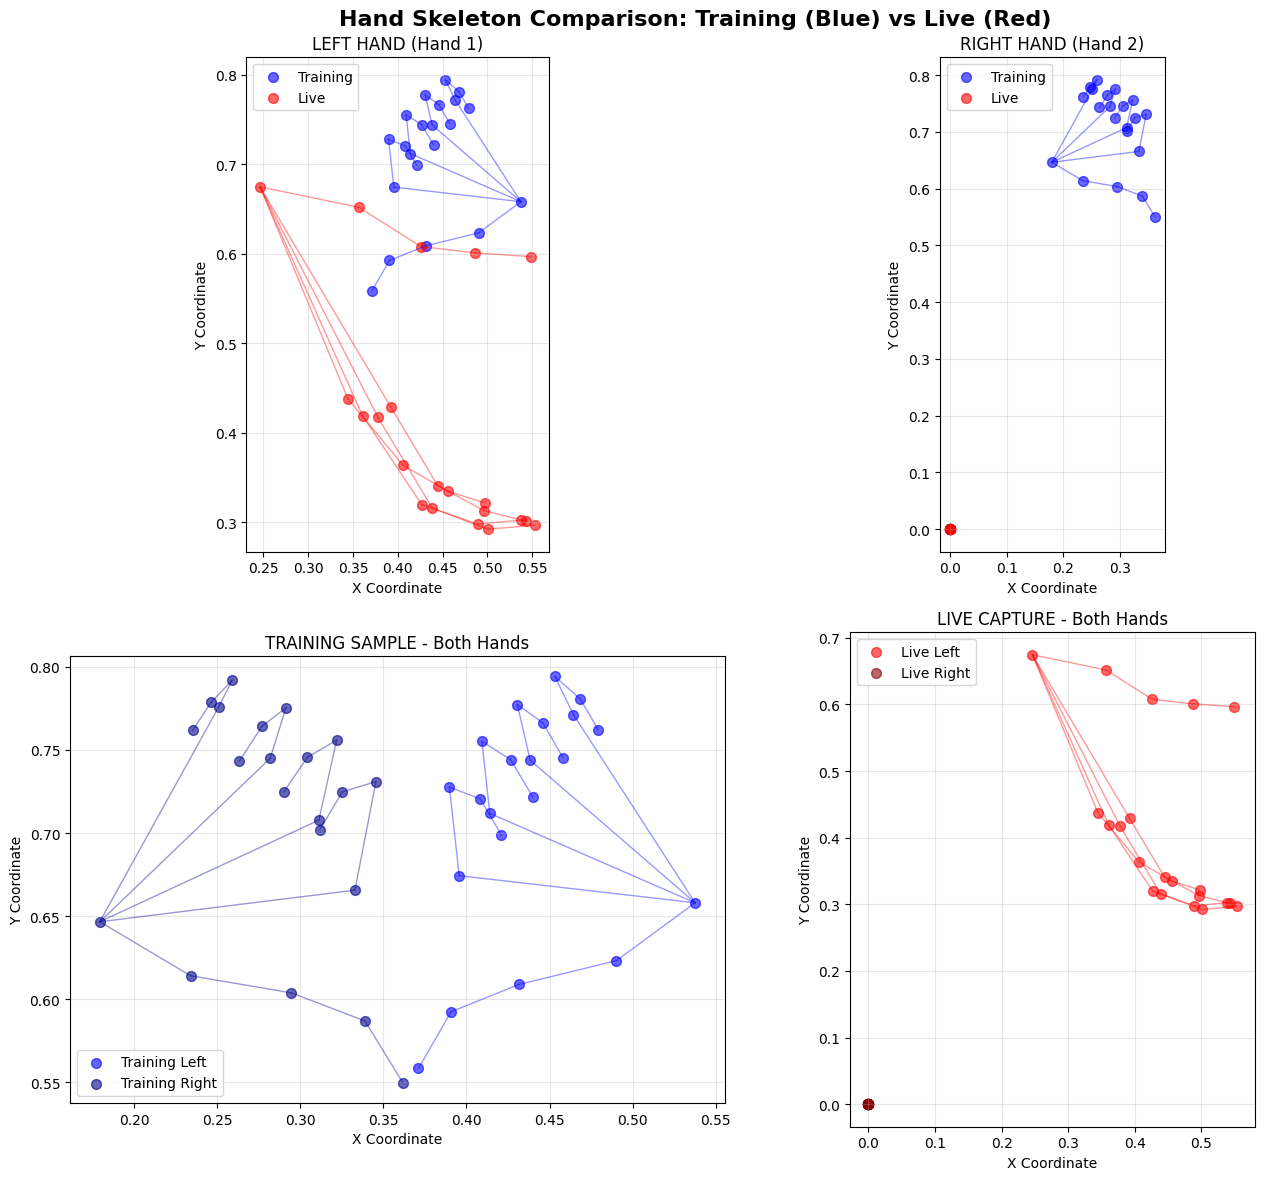


✓ Skeleton plots generated successfully

VISUAL DIAGNOSTICS:
  - If skeletons overlap: Coordinates are aligned ✓
  - If skeletons don't overlap: Check normalization or coordinate system
  - If RED is mirrored across vertical axis: Image orientation mismatch
  - If RED is shifted: Systematic offset in coordinate extraction


In [7]:
# Define hand skeleton connections (MediaPipe format)
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),      # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),      # Index
    (0, 9), (9, 10), (10, 11), (11, 12), # Middle
    (0, 13), (13, 14), (14, 15), (15, 16), # Ring
    (0, 17), (17, 18), (18, 19), (19, 20), # Pinky
]

def plot_hand_skeleton(ax, landmarks_1d, color, label, hand_offset=0):
    """Plot hand skeleton on axis."""
    # Extract hand landmarks (21 landmarks × 3 coords)
    hand_start = hand_offset * 63
    hand_end = hand_start + 63
    hand_landmarks = landmarks_1d[hand_start:hand_end].reshape(21, 3)
    
    # Plot landmarks
    x_coords = hand_landmarks[:, 0]
    y_coords = hand_landmarks[:, 1]
    ax.scatter(x_coords, y_coords, c=color, s=50, alpha=0.6, label=label)
    
    # Plot connections
    for connection in HAND_CONNECTIONS:
        start_idx, end_idx = connection
        x_line = [hand_landmarks[start_idx, 0], hand_landmarks[end_idx, 0]]
        y_line = [hand_landmarks[start_idx, 1], hand_landmarks[end_idx, 1]]
        ax.plot(x_line, y_line, color=color, alpha=0.4, linewidth=1)

if training_sample is not None and live_sequence is not None:
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('Hand Skeleton Comparison: Training (Blue) vs Live (Red)', fontsize=16, fontweight='bold')
    
    # Prepare frames
    train_frame_0 = training_sample[0] if training_sample.ndim == 2 else training_sample
    live_frame_0 = live_sequence[0]
    
    # Flatten if needed
    if train_frame_0.ndim == 2:
        train_frame_0 = train_frame_0.flatten()[:126]
    if live_frame_0.ndim == 2:
        live_frame_0 = live_frame_0.flatten()[:126]
    
    # Plot 1: Left Hand Only
    ax1 = axes[0, 0]
    plot_hand_skeleton(ax1, train_frame_0, 'blue', 'Training', hand_offset=0)
    plot_hand_skeleton(ax1, live_frame_0, 'red', 'Live', hand_offset=0)
    ax1.set_xlabel('X Coordinate')
    ax1.set_ylabel('Y Coordinate')
    ax1.set_title('LEFT HAND (Hand 1)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal', adjustable='box')
    
    # Plot 2: Right Hand Only
    ax2 = axes[0, 1]
    plot_hand_skeleton(ax2, train_frame_0, 'blue', 'Training', hand_offset=1)
    plot_hand_skeleton(ax2, live_frame_0, 'red', 'Live', hand_offset=1)
    ax2.set_xlabel('X Coordinate')
    ax2.set_ylabel('Y Coordinate')
    ax2.set_title('RIGHT HAND (Hand 2)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')
    
    # Plot 3: Both hands overlaid (Training)
    ax3 = axes[1, 0]
    plot_hand_skeleton(ax3, train_frame_0, 'blue', 'Training Left', hand_offset=0)
    plot_hand_skeleton(ax3, train_frame_0, 'darkblue', 'Training Right', hand_offset=1)
    ax3.set_xlabel('X Coordinate')
    ax3.set_ylabel('Y Coordinate')
    ax3.set_title('TRAINING SAMPLE - Both Hands')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_aspect('equal', adjustable='box')
    
    # Plot 4: Both hands overlaid (Live)
    ax4 = axes[1, 1]
    plot_hand_skeleton(ax4, live_frame_0, 'red', 'Live Left', hand_offset=0)
    plot_hand_skeleton(ax4, live_frame_0, 'darkred', 'Live Right', hand_offset=1)
    ax4.set_xlabel('X Coordinate')
    ax4.set_ylabel('Y Coordinate')
    ax4.set_title('LIVE CAPTURE - Both Hands')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Skeleton plots generated successfully")
    print("\nVISUAL DIAGNOSTICS:")
    print("  - If skeletons overlap: Coordinates are aligned ✓")
    print("  - If skeletons don't overlap: Check normalization or coordinate system")
    print("  - If RED is mirrored across vertical axis: Image orientation mismatch")
    print("  - If RED is shifted: Systematic offset in coordinate extraction")

## Section 6: Prediction Confidence

Feed both training sample and live sequence through the model and compare raw softmax probabilities to diagnose if input mismatches affect predictions.


In [8]:
def predict_and_analyze(features, model, class_mapping, label):
    """Run prediction and return probabilities."""
    try:
        # Prepare input
        if features.ndim == 1:
            features = features.reshape(1, 1, -1)  # (1, 1, 126)
        elif features.ndim == 2:
            features = features.reshape(1, features.shape[0], features.shape[1])  # (1, seq_len, 126)
        
        features_tensor = torch.from_numpy(features).float().to(DEVICE)
        seq_length = torch.tensor([features.shape[1]]).to(DEVICE)
        
        with torch.no_grad():
            logits = model(features_tensor, seq_length)
            
            # Handle CTC output (T, B, C) or standard (B, C)
            if logits.dim() == 3:
                logits = logits.mean(dim=0)  # Average over time
            
            probs = torch.softmax(logits, dim=1)
            class_id = torch.argmax(logits, dim=1).item()
            confidence = probs[0, class_id].item()
        
        return probs.cpu().numpy()[0], class_id, confidence
    
    except Exception as e:
        print(f"ERROR in {label}: {str(e)}")
        return None, None, None

if training_sample is not None and live_sequence is not None:
    print("\n" + "="*90)
    print("MODEL PREDICTION COMPARISON")
    print("="*90)
    
    # Predict training sample
    print("\n1. TRAINING SAMPLE PREDICTION:")
    print("-" * 90)
    train_probs, train_class_id, train_conf = predict_and_analyze(
        training_sample, model, class_mapping, "Training"
    )
    
    if train_probs is not None:
        train_class_name = class_mapping.get(train_class_id, f"Class_{train_class_id}")
        if isinstance(train_class_name, str) and train_class_name.startswith('ISL_'):
            train_class_name = train_class_name.replace('ISL_', '')
        
        print(f"Predicted Class: {train_class_name} (ID: {train_class_id})")
        print(f"Confidence: {train_conf*100:.2f}%")
        print(f"\nTop 5 predictions:")
        top5_indices = np.argsort(train_probs)[-5:][::-1]
        for rank, idx in enumerate(top5_indices, 1):
            class_name = class_mapping.get(idx, f"Class_{idx}")
            if isinstance(class_name, str) and class_name.startswith('ISL_'):
                class_name = class_name.replace('ISL_', '')
            print(f"  {rank}. {class_name}: {train_probs[idx]*100:.2f}%")
    
    # Predict live sequence
    print("\n2. LIVE SEQUENCE PREDICTION:")
    print("-" * 90)
    live_probs, live_class_id, live_conf = predict_and_analyze(
        live_sequence, model, class_mapping, "Live"
    )
    
    if live_probs is not None:
        live_class_name = class_mapping.get(live_class_id, f"Class_{live_class_id}")
        if isinstance(live_class_name, str) and live_class_name.startswith('ISL_'):
            live_class_name = live_class_name.replace('ISL_', '')
        
        print(f"Predicted Class: {live_class_name} (ID: {live_class_id})")
        print(f"Confidence: {live_conf*100:.2f}%")
        print(f"\nTop 5 predictions:")
        top5_indices = np.argsort(live_probs)[-5:][::-1]
        for rank, idx in enumerate(top5_indices, 1):
            class_name = class_mapping.get(idx, f"Class_{idx}")
            if isinstance(class_name, str) and class_name.startswith('ISL_'):
                class_name = class_name.replace('ISL_', '')
            print(f"  {rank}. {class_name}: {live_probs[idx]*100:.2f}%")
    
    # Comparison and diagnostics
    if train_probs is not None and live_probs is not None:
        print("\n3. COMPARISON & DIAGNOSTICS:")
        print("-" * 90)
        
        # Check if predictions match
        if train_class_id == live_class_id:
            print("✓ PREDICTIONS MATCH: Both samples predict the same class")
        else:
            print("✗ PREDICTIONS DIFFER:")
            print(f"  Training predicts: {class_mapping.get(train_class_id)}")
            print(f"  Live predicts: {class_mapping.get(live_class_id)}")
        
        # Confidence comparison
        conf_diff = live_conf - train_conf
        print(f"\nConfidence Difference: {conf_diff:+.4f}")
        if abs(conf_diff) < 0.05:
            print("  → Confidence levels are similar (good!)")
        elif conf_diff > 0.1:
            print("  → Live prediction is MORE confident (possible different hand position)")
        else:
            print("  → Live prediction is LESS confident (possible input mismatch)")
        
        # Probability distribution
        print(f"\nProbability Distribution Quality:")
        train_entropy = -np.sum(train_probs * np.log(train_probs + 1e-10))
        live_entropy = -np.sum(live_probs * np.log(live_probs + 1e-10))
        print(f"  Training entropy: {train_entropy:.4f}")
        print(f"  Live entropy: {live_entropy:.4f}")
        print(f"  (Lower entropy = more confident distribution)")
        
        # KL divergence
        kl_div = np.sum(train_probs * (np.log(train_probs + 1e-10) - np.log(live_probs + 1e-10)))
        print(f"\nKL Divergence (Train || Live): {kl_div:.6f}")
        if kl_div < 0.1:
            print("  → Probability distributions are very similar")
        elif kl_div < 0.5:
            print("  → Probability distributions are reasonably similar")
        else:
            print("  → Probability distributions are quite different (possible input mismatch!)")


MODEL PREDICTION COMPARISON

1. TRAINING SAMPLE PREDICTION:
------------------------------------------------------------------------------------------
Predicted Class: A (ID: 0)
Confidence: 53.60%

Top 5 predictions:
  1. A: 53.60%
  2. E: 16.09%
  3. F: 14.96%
  4. G: 3.34%
  5. N: 3.13%

2. LIVE SEQUENCE PREDICTION:
------------------------------------------------------------------------------------------
Predicted Class: Z (ID: 24)
Confidence: 97.16%

Top 5 predictions:
  1. Z: 97.16%
  2. V: 1.90%
  3. D: 0.66%
  4. M: 0.06%
  5. B: 0.06%

3. COMPARISON & DIAGNOSTICS:
------------------------------------------------------------------------------------------
✗ PREDICTIONS DIFFER:
  Training predicts: ISL_A
  Live predicts: ISL_Z

Confidence Difference: +0.4356
  → Live prediction is MORE confident (possible different hand position)

Probability Distribution Quality:
  Training entropy: 1.5340
  Live entropy: 0.1587
  (Lower entropy = more confident distribution)

KL Divergence (Tra

## Summary: Debugging Checklist

Use this checklist to identify and fix common training vs inference mismatches:

### Data Format Issues
- [ ] **Shape mismatch**: Training vs live sequences have different lengths
  - **Fix**: Ensure both use same max_seq_len (default: 60 frames)
  
- [ ] **Normalization**: Coordinates in different ranges
  - **Fix**: Apply wrist-relative normalization to both training and live data

### Coordinate System Issues
- [ ] **Mirroring**: Live capture shows horizontally flipped hands
  - **Fix**: Check if webcam video is flipped; ensure consistent handling

- [ ] **Offset**: Systematic X or Y shift in coordinates
  - **Fix**: Check if frame center or resolution changed between training/inference

### Hand Detection Issues
- [ ] **Handedness swap**: Left/right hands swapped between training and live
  - **Fix**: Ensure consistent hand ordering (e.g., always left-first)

- [ ] **Missing hands**: Live capture doesn't detect both hands
  - **Fix**: Lower MediaPipe detection confidence threshold

### Feature Extraction Issues
- [ ] **Smoothing**: Live data is too smooth/choppy compared to training
  - **Fix**: Tune One Euro Filter parameters (min_cutoff, beta)

- [ ] **Confidence mismatch**: Model confidence differs significantly
  - **Fix**: Check if preprocessing pipeline matches training exactly

### Model Input Issues
- [ ] **Tensor shape**: Model expects different input dimensions
  - **Fix**: Verify model input layer: should accept (batch, seq_len, 126)

- [ ] **Device mismatch**: Model on GPU but features on CPU
  - **Fix**: Ensure features moved to same device as model

---

**Next Steps**:
1. Review any mismatches identified above
2. Check preprocessing pipeline in [inference/feature_processing.py](../inference/feature_processing.py)
3. Compare with training pipeline in [preprocessing/preprocess.py](../preprocessing/preprocess.py)
4. Run this notebook again after making fixes
